In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Layer 3 Library: Vector Autoregression
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Layer 2 Library: PC Algorithm
# (Requires: pip install causal-learn)
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Stage 0 Complete: Data Generated for 7 Parameters.
               Sleep  Glucose  Activity
Continent                              
Africa          71.9     74.7    9132.2
Asia            62.9    106.1    6704.4
Europe          76.4     52.5   10742.6
North America   72.4     69.1    9319.7
South America   72.1     59.4   11328.4


Stage 1 Complete: Data Split.
   Training Samples: 1200
   Testing Samples: 300 (Continent: Asia)

Domain shift check: mean values by continent
               Sleep  Mood  Activity   RHR    HRV  VO2_Max  Glucose
Continent                                                          
Africa         71.89  7.18   9132.22  3.51  39.31    20.02    74.71
Asia           62.92  6.21   6704.36  7.97  34.94    15.71   106.06
Europe         76.44  7.47  10742.64  2.31  34.65    23.09    52.50
North America  72.40  7.36   9319.68  3.32  35.80    20.76    69.12
South America  72.06  7.19  11328.40  4.29  34.26    24.31    59.35

Asia vs Rest-of-World (mean differences):
          Asia - RestOfWorld
Sleep                 -10.28
Mood                   -1.09
Activity            -3426.38
RHR                     4.61
HRV                    -1.07
VO2_Max                -6.33
Glucose                42.13

Standardized mean differences (in SD units):
          StdDiff (Asia vs RoW)
Sleep                     -

Stage 2: Running PC Algorithm...


Depth=3, working on node 6: 100%|██████████| 7/7 [00:00<00:00, 1224.82it/s]

Stage 2 Complete: Causal topology discovered.

Directed / candidate parents per node:
  Sleep: ['Glucose', 'HRV', 'Mood']
  Mood: ['HRV']
  Activity: ['Glucose', 'HRV', 'Mood', 'VO2_Max']
  RHR: ['Glucose', 'HRV', 'VO2_Max']
  HRV: ['Mood']
  VO2_Max: ['Glucose']
  Glucose: ['VO2_Max']


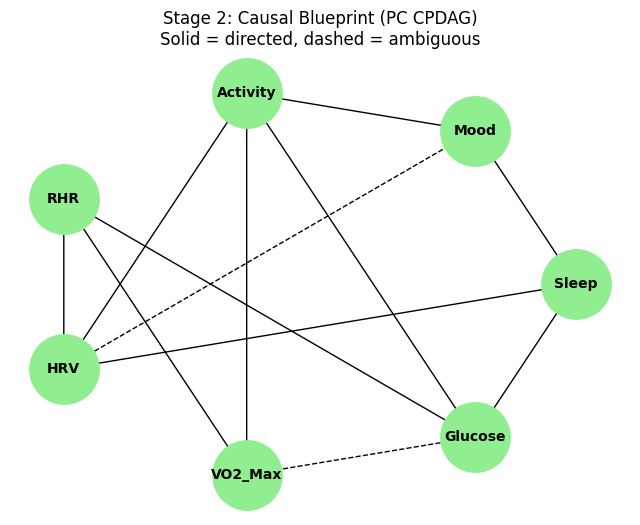

In [4]:
# STAGE 2: CAUSAL DISCOVERY (PC Algorithm, improved)

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

print("Stage 2: Running PC Algorithm...")

# 1. Prepare data for PC
data_matrix = df_train.to_numpy()
labels = list(df_train.columns)
n_vars = len(labels)

# 2. Run PC
# alpha = 0.05, indep_test = 'fisherz' are standard for continuous data
cg = pc(data_matrix, alpha=0.05, indep_test='fisherz', verbose=False)

# 3. Extract edge types from CPDAG adjacency matrix
# Docs: cg.G.graph[j,i] = 1 and cg.G.graph[i,j] = -1 -> i -> j
adj = cg.G.graph

edges = []                      # list of (u, v, edge_type)
parents = {v: set() for v in labels}   # parents per node

for i in range(n_vars):
    for j in range(i + 1, n_vars):  # upper triangle to avoid duplicate pairs
        a_ij = adj[i, j]
        a_ji = adj[j, i]

        # No edge
        if a_ij == 0 and a_ji == 0:
            continue

        # i -> j
        if a_ji == 1 and a_ij == -1:
            u, v, etype = labels[i], labels[j], 'directed'
            edges.append((u, v, etype))
            parents[v].add(u)

        # j -> i
        elif a_ij == 1 and a_ji == -1:
            u, v, etype = labels[j], labels[i], 'directed'
            edges.append((u, v, etype))
            parents[v].add(u)

        # undirected edge (i — j): orientation ambiguous in CPDAG
        elif a_ij == -1 and a_ji == -1:
            u, v, etype = labels[i], labels[j], 'undirected'
            edges.append((u, v, etype))
            # optional: treat both as candidate parents of each other
            parents[u].add(v)
            parents[v].add(u)

        # bi-directed (i <-> j); unusual for plain PC but defined in docs
        elif a_ij == 1 and a_ji == 1:
            u, v, etype = labels[i], labels[j], 'bidirected'
            edges.append((u, v, etype))
            parents[u].add(v)
            parents[v].add(u)

print("Stage 2 Complete: Causal topology discovered.\n")

print("Directed / candidate parents per node:")
for v in labels:
    print(f"  {v}: {sorted(parents[v])}")

# 4. Visualization with networkx

G_pc = nx.DiGraph()
G_pc.add_nodes_from(labels)

# Add edges with style metadata
for u, v, etype in edges:
    if etype == 'directed':
        G_pc.add_edge(u, v, style='solid')
    elif etype in ('undirected', 'bidirected'):
        # for layout, add a single undirected logical edge, but no arrows
        G_pc.add_edge(u, v, style='dashed')

plt.figure(figsize=(8, 6))
pos = nx.circular_layout(G_pc)

nx.draw_networkx_nodes(G_pc, pos, node_color='lightgreen', node_size=2500)
nx.draw_networkx_labels(G_pc, pos, font_weight='bold', font_size=10)

solid_edges = [(u, v) for u, v, d in G_pc.edges(data=True) if d.get('style') == 'solid']
dashed_edges = [(u, v) for u, v, d in G_pc.edges(data=True) if d.get('style') == 'dashed']

nx.draw_networkx_edges(
    G_pc, pos,
    edgelist=solid_edges,
    arrows=True,
    arrowsize=20
)
nx.draw_networkx_edges(
    G_pc, pos,
    edgelist=dashed_edges,
    arrows=False,
    style='dashed'
)

plt.title("Stage 2: Causal Blueprint (PC CPDAG)\nSolid = directed, dashed = ambiguous")
plt.axis("off")
plt.show()

# 'parents' is now ready to be used to constrain your temporal model in Stage 3+


In [11]:
# # STEP 3: LAYER 3 - TEMPORAL DYNAMICS (VAR Model)
# # Goal: Quantify the *strength* and *timing* of the edges found in Layer 2.
# model = VAR(df_train)

# # We use Lag 2 here (looking back 2 days)
# results = model.fit(maxlags=2) 

# print("\nStage 3 Complete: Model Trained.")
# print("   Checking Logic: Does 'Activity' lower 'Glucose'?")

# # Row = The Cause (Activity yesterday -> L1.Activity)
# # Column = The Effect (Glucose today)
# coef = results.params.loc['L1.Activity', 'Glucose']

# print(f"   Coefficient (Activity -> Glucose): {coef:.5f} ({'Correct (Negative)' if coef < 0 else 'Incorrect'})")

# STAGE 3: LAYER 3 - TEMPORAL DYNAMICS (VAR Model, improved)

from statsmodels.tsa.api import VAR

print("\nStage 3: Fitting VAR model...")

# 1. Fit VAR
# You can either fix lag_order=2 explicitly, or let the model pick via an info criterion.
# Here: let it search up to 4 and pick best by AIC, then we'll use that.
model = VAR(df_train)
results = model.fit(maxlags=4, ic='aic')   # you can change maxlags if you want

lag_order = results.k_ar
var_names = df_train.columns.tolist()
k = len(var_names)

print(f"Stage 3 Complete: VAR fitted with lag order = {lag_order}")

# 2. Extract coefficient tensors
# results.coefs has shape (lag_order, k_endog, k_endog)
# coefs[lag-1, i, j] = effect of variable j at t-lag on variable i at t
coefs = results.coefs

# Sanity check shape
print(f"Coefficient tensor shape: {coefs.shape} (lags, n_vars, n_vars)")
print("Variable order:", var_names)

# 3. Check logic: does Activity lower Glucose?

print("\nChecking logic: Does past Activity lower Glucose?")

try:
    activity_idx = var_names.index('Activity')
    glucose_idx = var_names.index('Glucose')
except ValueError as e:
    raise ValueError("Expected 'Activity' and 'Glucose' in df_train columns") from e

# For each lag, inspect the coefficient: Activity(t-lag) -> Glucose(t)
activity_to_glucose = []
for lag in range(1, lag_order + 1):
    coef_lag = coefs[lag - 1, glucose_idx, activity_idx]
    activity_to_glucose.append(coef_lag)
    sign = "negative (glucose down with higher activity)" if coef_lag < 0 else "positive"
    print(f"  Lag {lag}: coef = {coef_lag:.5f} ({sign})")

total_effect = sum(activity_to_glucose)
print(f"\nTotal linear effect across {lag_order} lags: {total_effect:.5f} "
      f"({'overall negative' if total_effect < 0 else 'overall positive'})")

# Optional: formal Granger causality test
try:
    causality_res = results.test_causality(
        caused='Glucose',
        causing=['Activity'],
        kind='wald'
    )
    print("\nGranger causality test: Activity → Glucose")
    print(f"  p-value: {causality_res.pvalue:.4f}")
    print("  => ", "Reject no-causality (Activity helps predict Glucose)"
                  if causality_res.pvalue < 0.05
                  else "Cannot reject no-causality at 0.05 level")
except Exception as e:
    print("Could not run Granger causality test:", e)



Stage 3: Fitting VAR model...
Stage 3 Complete: VAR fitted with lag order = 1
Coefficient tensor shape: (1, 7, 7) (lags, n_vars, n_vars)
Variable order: ['Sleep', 'Mood', 'Activity', 'RHR', 'HRV', 'VO2_Max', 'Glucose']

Checking logic: Does past Activity lower Glucose?
  Lag 1: coef = -0.00093 (negative (glucose down with higher activity))

Total linear effect across 1 lags: -0.00093 (overall negative)

Granger causality test: Activity → Glucose
  p-value: 0.0000
  =>  Reject no-causality (Activity helps predict Glucose)


/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



Stage 4: Visualizing lag-1 coefficient matrix...


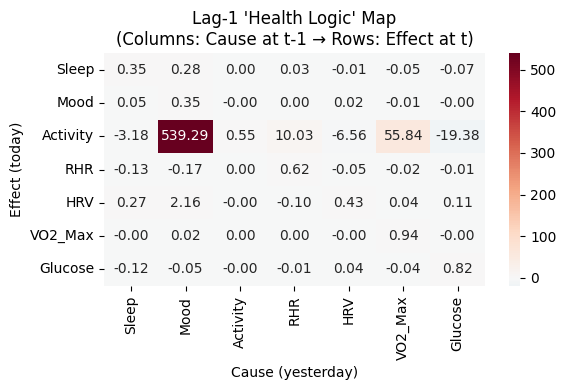

In [14]:

# STAGE 4: VISUALIZE THE NETWORK (cleaned-up heatmap)

print("\nStage 4: Visualizing lag-1 coefficient matrix...")

import pandas as pd

if lag_order >= 1:
    # Extract lag-1 coefficient matrix: effect of variables at t-1 on variables at t
    matrix_l1 = pd.DataFrame(
        coefs[0],        # lag 1 = index 0
        index=var_names, # rows: "Effect at time t"
        columns=var_names # columns: "Cause at time t-1"
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix_l1, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
    plt.title("Lag-1 'Health Logic' Map\n(Columns: Cause at t-1 → Rows: Effect at t)")
    plt.ylabel("Effect (today)")
    plt.xlabel("Cause (yesterday)")
    plt.tight_layout()
    plt.show()
else:
    print("Model chose lag_order = 0, no temporal structure to visualize.")


Stage 5: Running Simulations...


<Figure size 640x480 with 0 Axes>

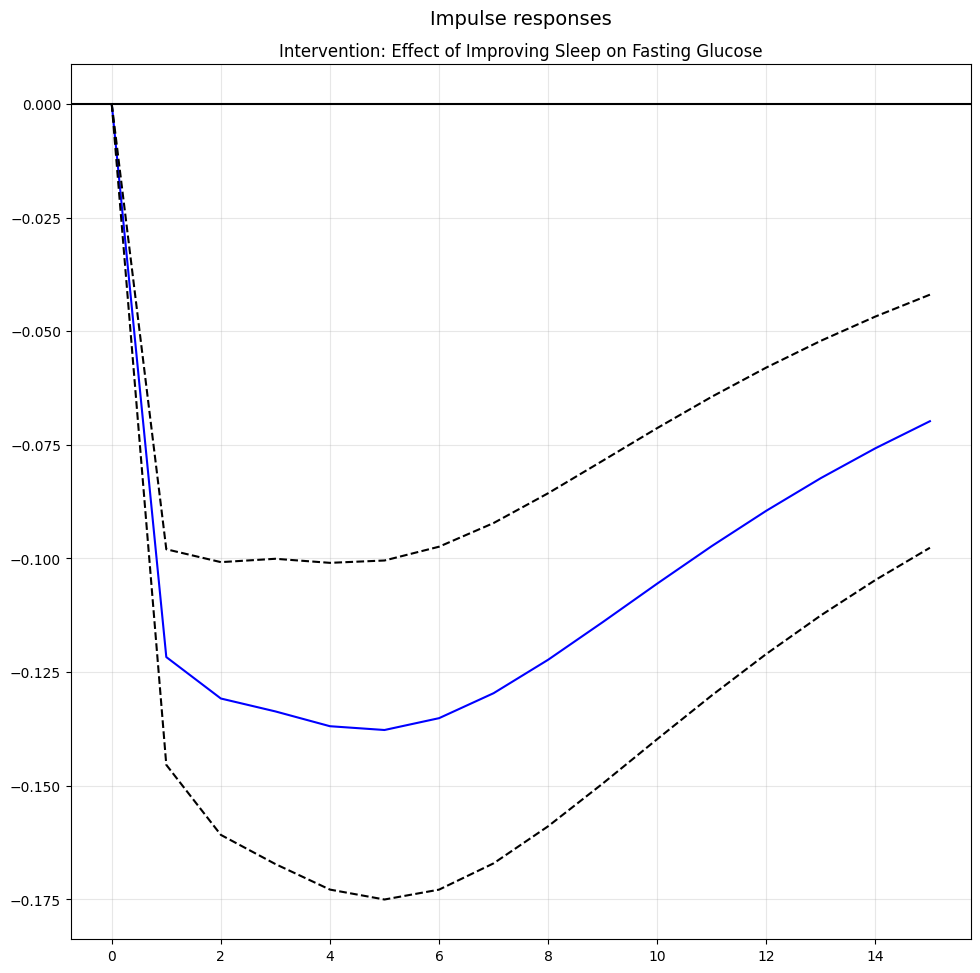

<Figure size 640x480 with 0 Axes>

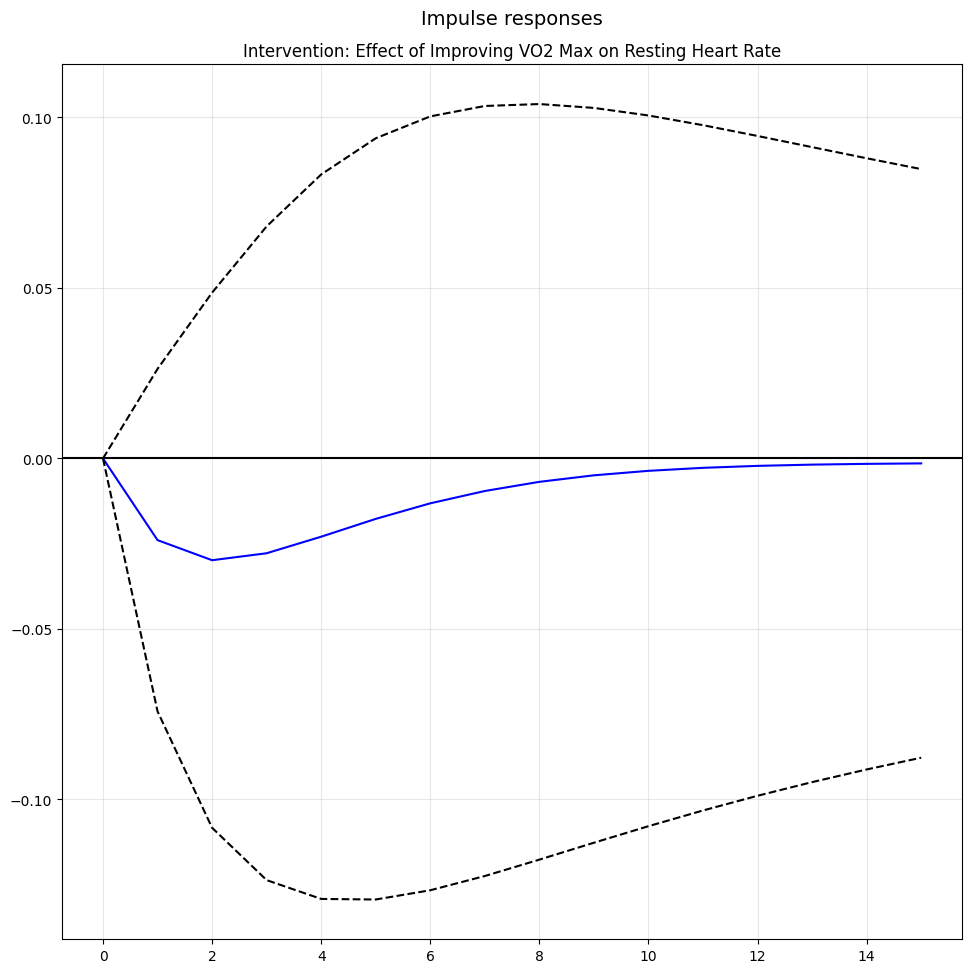

In [19]:
# STAGE 5: INTERVENTION SIMULATION
print("\nStage 5: Running Simulations...")

# Scenario 1: "If I force myself to Sleep better, what happens to my Glucose?"
irf = results.irf(15) # 15 days projection

plt.figure() 
irf.plot(impulse='Sleep', response='Glucose')
plt.title("Intervention: Effect of Improving Sleep on Fasting Glucose")
plt.grid(True, alpha=0.3)
plt.show()

# Scenario 2: "If I improve my VO2 Max (get fitter), does my RHR go down?"
plt.figure()
irf.plot(impulse='VO2_Max', response='RHR')
plt.title("Intervention: Effect of Improving VO2 Max on Resting Heart Rate")
plt.grid(True, alpha=0.3)
plt.show()


Running Stage 6: Validation...


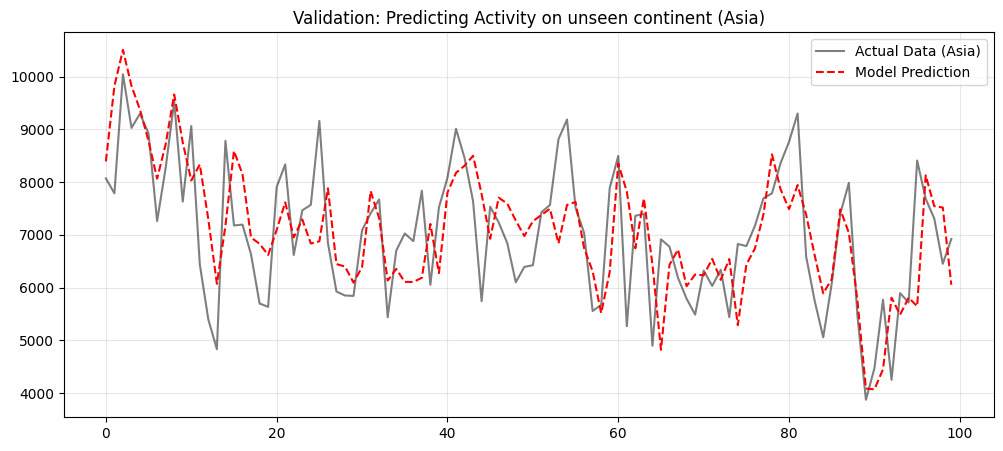

Validation Complete. RMSE on Unseen Data: 989.71


<Figure size 800x600 with 0 Axes>

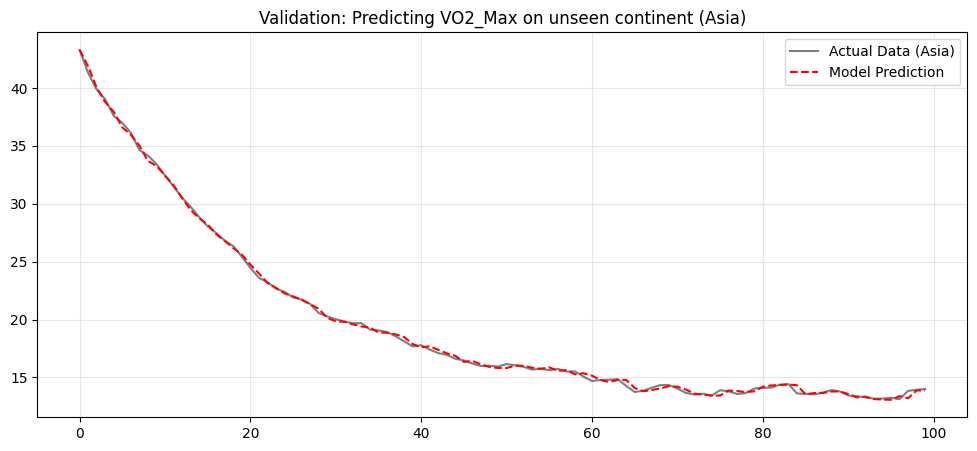

Validation Complete. RMSE on Unseen Data: 0.21


<Figure size 800x600 with 0 Axes>

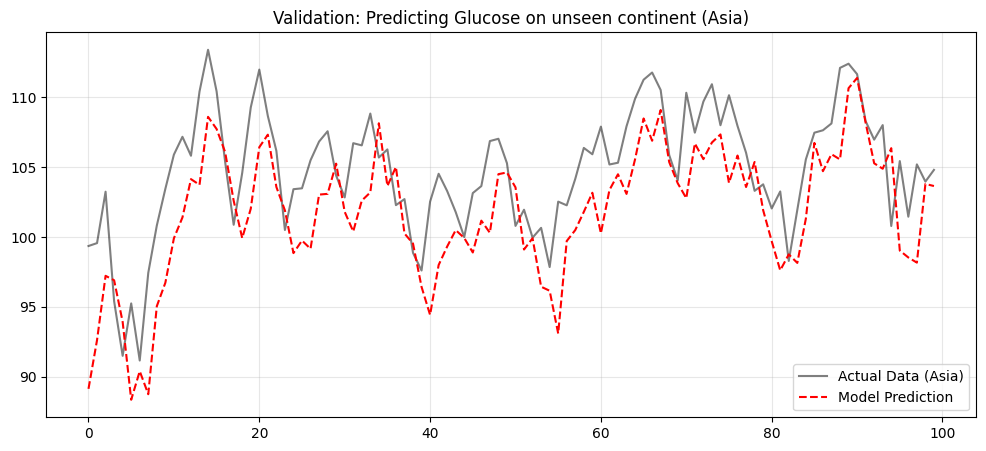

Validation Complete. RMSE on Unseen Data: 4.13


<Figure size 800x600 with 0 Axes>

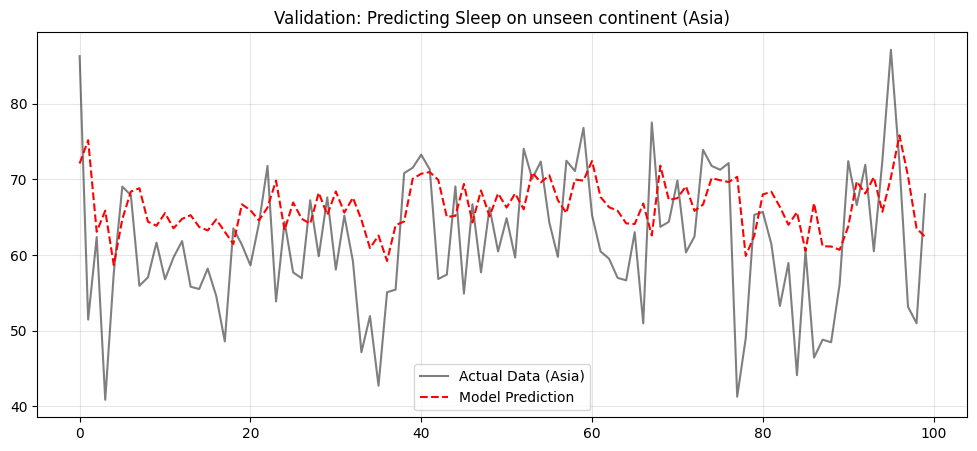

Validation Complete. RMSE on Unseen Data: 9.03


<Figure size 800x600 with 0 Axes>

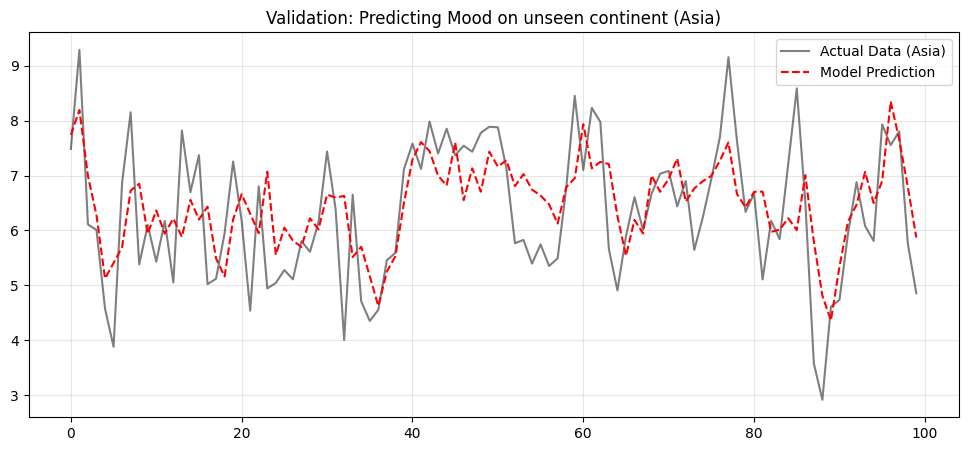

Validation Complete. RMSE on Unseen Data: 1.06


<Figure size 800x600 with 0 Axes>

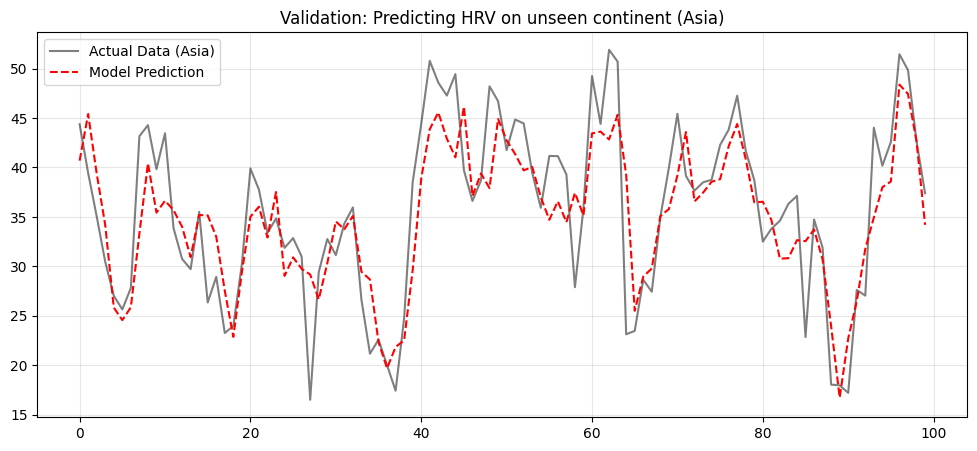

Validation Complete. RMSE on Unseen Data: 5.23


<Figure size 800x600 with 0 Axes>

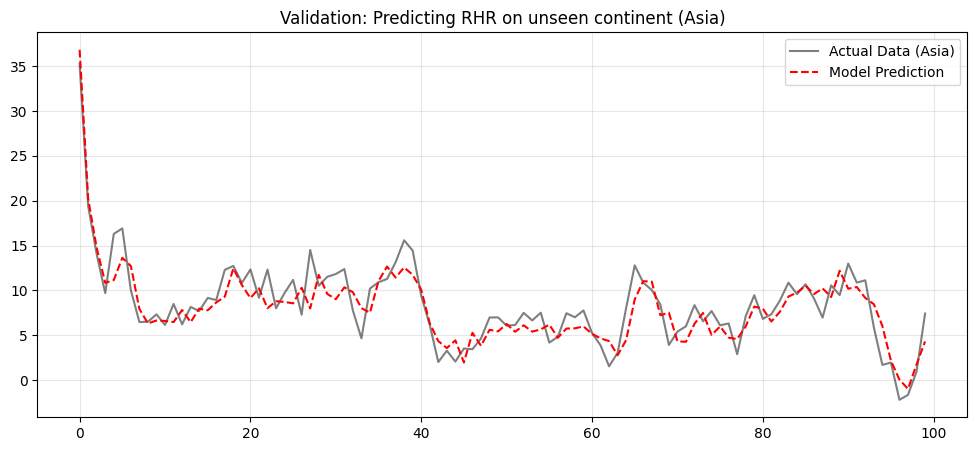

Validation Complete. RMSE on Unseen Data: 2.22


In [8]:

# STAGE 6: VALIDATION ON UNSEEN DATA
print("\nRunning Stage 6: Validation...")

# 1. Prepare Test Data
# We extract the raw numpy array to avoid the Index Warning you saw earlier.
test_values = df_test.values
lag_order = results.k_ar

predictions = []
actuals = []

# 2. Walk-Forward Validation
# For every day in the test set, use the previous 2 days (Lag 2) to predict today.
for i in range(lag_order, len(test_values)):
    # Input: The previous 'lag_order' days from the test set
    forecast_input = test_values[i-lag_order:i] 
    
    # Predict: The next single step
    pred = results.forecast(y=forecast_input, steps=1)
    
    predictions.append(pred[0])
    actuals.append(test_values[i])

# 3. Organize Results into DataFrames
pred_df = pd.DataFrame(predictions, columns=df_test.columns)
act_df = pd.DataFrame(actuals, columns=df_test.columns)

# 4. Visualize Accuracy (Focus on 'Activity')
def plot_validation(act_df, pred_df, variable):
    plt.figure(figsize=(12, 5))
    limit = 100 # Zoom in on the first 100 days for clarity
    plt.plot(act_df[variable][:limit].values, label='Actual Data (Asia)', color='black', alpha=0.5)
    plt.plot(pred_df[variable][:limit].values, label='Model Prediction', color='red', linestyle='--')
    plt.title(f"Validation: Predicting {variable} on unseen continent (Asia)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. Score the Model
    rmse = np.sqrt(mean_squared_error(act_df[variable], pred_df[variable]))
    print(f"Validation Complete. RMSE on Unseen Data: {rmse:.2f}")

plot_validation(act_df, pred_df, 'Activity')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'VO2_Max')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Glucose')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Sleep')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Mood')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'HRV')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'RHR')
